# Logistic Regression with SMOTE for Class Imbalance
## Steam Games Dataset Analysis

This notebook applies **Logistic Regression** combined with **SMOTE (Synthetic Minority Over-sampling Technique)**
to handle class imbalance in the Steam games dataset.

### Key Concepts:
- **Data Cleaning**: Comprehensive preprocessing from the Linear Regression guide
- **Correlation Analysis**: Identify feature relationships and multicollinearity
- **Logistic Regression**: Linear classifier with sigmoid function for binary classification
- **SMOTE**: Synthetic data generation to balance minority class
- **Regularization**: L1 and L2 penalties with hyperparameter tuning
- **Class Imbalance**: Handling skewed datasets where one class is underrepresented

In [79]:
import warnings
warnings.filterwarnings('ignore')
import ast
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from collections import Counter

# SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

pd.options.display.float_format = '{:,.2g}'.format

In [80]:
# Ensure imbalanced-learn is installed
import subprocess
import sys

try:
    from imblearn.over_sampling import SMOTE
    print("imbalanced-learn is already installed.")
except ImportError:
    print("Installing imbalanced-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    print("Installation complete.")

imbalanced-learn is already installed.


## I. Loading the Dataset

Load the Steam games dataset for preprocessing and analysis.

In [81]:
df = pd.read_csv('games_steam.csv')
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset Shape: (94954, 44)

Column Names:
['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'detailed_description', 'about_the_game', 'short_description', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'achievements', 'recommendations', 'supported_languages', 'full_audio_languages', 'packages', 'developers', 'publishers', 'categories', 'genres', 'screenshots', 'movies', 'user_score', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent']

First few rows:


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,7.3e+02,Counter-Strike 2,8/21/2012,0,0,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,5.8e+05,PUBG: BATTLEGROUNDS,12/21/2017,0,0,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,5.7e+02,Dota 2,7/9/2013,0,0,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,2.7e+05,Grand Theft Auto V Legacy,4/13/2015,17,0,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,4.9e+05,Tom Clancy's Rainbow Six® Siege,12/1/2015,17,20,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,0,0,0,0,0,"{'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...",84,1168404,76,13017


## II. Data Quality Assessment

Examine data types and identify missing values.

In [82]:
print("Data Types:")
print(df.dtypes)
print("\nMissing Values Summary:")
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False).head(20))

Data Types:
appid                       float64
name                            str
release_date                    str
required_age                float64
price                       float64
dlc_count                   float64
detailed_description            str
about_the_game                  str
short_description               str
reviews                         str
header_image                    str
website                         str
support_url                     str
support_email                   str
windows                      object
mac                          object
linux                        object
metacritic_score             object
achievements                 object
recommendations              object
supported_languages             str
full_audio_languages            str
packages                        str
developers                      str
publishers                      str
categories                      str
genres                          str
screenshots     

## III. Comprehensive Data Cleaning

Apply the data cleaning methodology from the Linear Regression guide:
- Remove unnamed columns
- Drop columns with excessive missing values
- Remove irrelevant features
- Clean numeric data
- Encode categorical and multi-label features

In [83]:
# Remove unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Create a copy for cleaning
df_clean = df.copy()

# Remove extra spaces from column names
df_clean.columns = df_clean.columns.str.strip()

# Remove columns with too many missing values (> 20,000 NaNs)
threshold = 20000
df_clean = df_clean.loc[:, df_clean.isna().sum() <= threshold]

# Drop irrelevant columns
cols_to_drop = [
    "appid", "screenshots", "about_the_game", "short_description",
    "website", "support_url", "support_email", "movies", "header_image",
    "release_date", "detailed_description", "packages",
    "average_playtime_2weeks", "median_playtime_forever",
    "median_playtime_2weeks", "positive", "negative",
    "pct_pos_total", "pct_pos_recent", "num_reviews_total",
    "num_reviews_recent", "peak_ccu", "recommendations",
]

df_clean = df_clean.drop(columns=cols_to_drop, errors="ignore")

# Clean numeric series
def clean_numeric_series(series):
    return pd.to_numeric(
        series.astype(str)
        .str.strip()
        .str.replace(r"^id_", "", regex=True)
        .str.replace(r"_x$", "", regex=True)
        .str.replace("$", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan),
        errors="coerce"
    )

numeric_cols = df_clean.select_dtypes(include=np.number).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(
    df_clean[numeric_cols].median()
)

print("Shape after initial cleaning:", df_clean.shape)
print("Missing values after cleaning:", df_clean.isnull().sum().sum())

Shape after initial cleaning: (94954, 18)
Missing values after cleaning: 28071


In [84]:
df_clean = df_clean.dropna()
print("Final cleaned shape:", df_clean.shape)
print("Columns:", df_clean.columns.tolist())

Final cleaned shape: (88131, 18)
Columns: ['name', 'required_age', 'price', 'dlc_count', 'windows', 'mac', 'linux', 'metacritic_score', 'achievements', 'supported_languages', 'developers', 'publishers', 'categories', 'genres', 'user_score', 'estimated_owners', 'average_playtime_forever', 'discount']


In [85]:
# Convert boolean columns
bool_cols = ["windows", "mac", "linux"]
df_clean[bool_cols] = df_clean[bool_cols].apply(
    lambda col: col.astype(str).str.strip().str.upper().map({
        "TRUE": 1,
        "FALSE": 0
    })
)

# Convert list columns
list_cols = ["supported_languages", "developers", "publishers", "categories", "genres"]
for col in list_cols:
    df_clean[col] = df_clean[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

print("Data types after conversion:")
print(df_clean.dtypes)

Data types after conversion:
name                            str
required_age                float64
price                       float64
dlc_count                   float64
windows                       int64
mac                           int64
linux                         int64
metacritic_score             object
achievements                 object
supported_languages          object
developers                   object
publishers                   object
categories                   object
genres                       object
user_score                   object
estimated_owners                str
average_playtime_forever     object
discount                     object
dtype: object


### Encoding Multi-Label Features

Convert categorical features into binary encoded columns using MultiLabelBinarizer.

In [86]:
# Encode supported languages
mlb = MultiLabelBinarizer()
lang_encoded = mlb.fit_transform(df_clean["supported_languages"])
lang_df = pd.DataFrame(lang_encoded, columns=[f"lang_{c}" for c in mlb.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, lang_df], axis=1)
print(f"Languages encoded: {lang_df.shape[1]} features")

Languages encoded: 107 features


In [87]:
# Encode top developers
top_devs = df_clean["developers"].explode().value_counts().head(100).index
df_clean["developers_filtered"] = df_clean["developers"].apply(
    lambda x: [i for i in x if i in top_devs]
)
mlb = MultiLabelBinarizer()
dev_encoded = mlb.fit_transform(df_clean["developers_filtered"])
dev_df = pd.DataFrame(dev_encoded, columns=[f"dev_{c}" for c in mlb.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, dev_df], axis=1)
print(f"Top 100 developers encoded: {dev_df.shape[1]} features")

Top 100 developers encoded: 100 features


In [88]:
# Encode top publishers
top_pub = df_clean["publishers"].explode().value_counts().head(100).index
df_clean["publishers_filtered"] = df_clean["publishers"].apply(
    lambda x: [i for i in x if i in top_pub]
)
mlb_pub = MultiLabelBinarizer()
pub_encoded = mlb_pub.fit_transform(df_clean["publishers_filtered"])
pub_df = pd.DataFrame(
    pub_encoded,
    columns=[f"pub_{c}" for c in mlb_pub.classes_],
    index=df_clean.index
)
df_clean = pd.concat([df_clean, pub_df], axis=1)
print(f"Top 100 publishers encoded: {pub_df.shape[1]} features")

Top 100 publishers encoded: 100 features


In [89]:
# Encode categories
mlb_cat = MultiLabelBinarizer()
cat_encoded = mlb_cat.fit_transform(df_clean["categories"])
cat_df = pd.DataFrame(
    cat_encoded,
    columns=[f"cat_{c}" for c in mlb_cat.classes_],
    index=df_clean.index
)
df_clean = pd.concat([df_clean, cat_df], axis=1)
print(f"Categories encoded: {cat_df.shape[1]} features")

Categories encoded: 40 features


In [90]:
# Encode genres
mlb_gen = MultiLabelBinarizer()
gen_encoded = mlb_gen.fit_transform(df_clean["genres"])
gen_df = pd.DataFrame(
    gen_encoded,
    columns=[f"genre_{c}" for c in mlb_gen.classes_],
    index=df_clean.index
)
df_clean = pd.concat([df_clean, gen_df], axis=1)
print(f"Genres encoded: {gen_df.shape[1]} features")
print(f"\nFinal dataset shape: {df_clean.shape}")

Genres encoded: 33 features

Final dataset shape: (88131, 400)


In [91]:
# Drop original multi-label columns
df_clean = df_clean.drop(columns=[
    "supported_languages", "developers", "publishers", "categories", "genres",
    "developers_filtered", "publishers_filtered"
])

print(f"Final cleaned dataset shape: {df_clean.shape}")

Final cleaned dataset shape: (88131, 393)


## IV. Correlation Analysis

Analyze feature correlations to identify multicollinearity and redundant features.

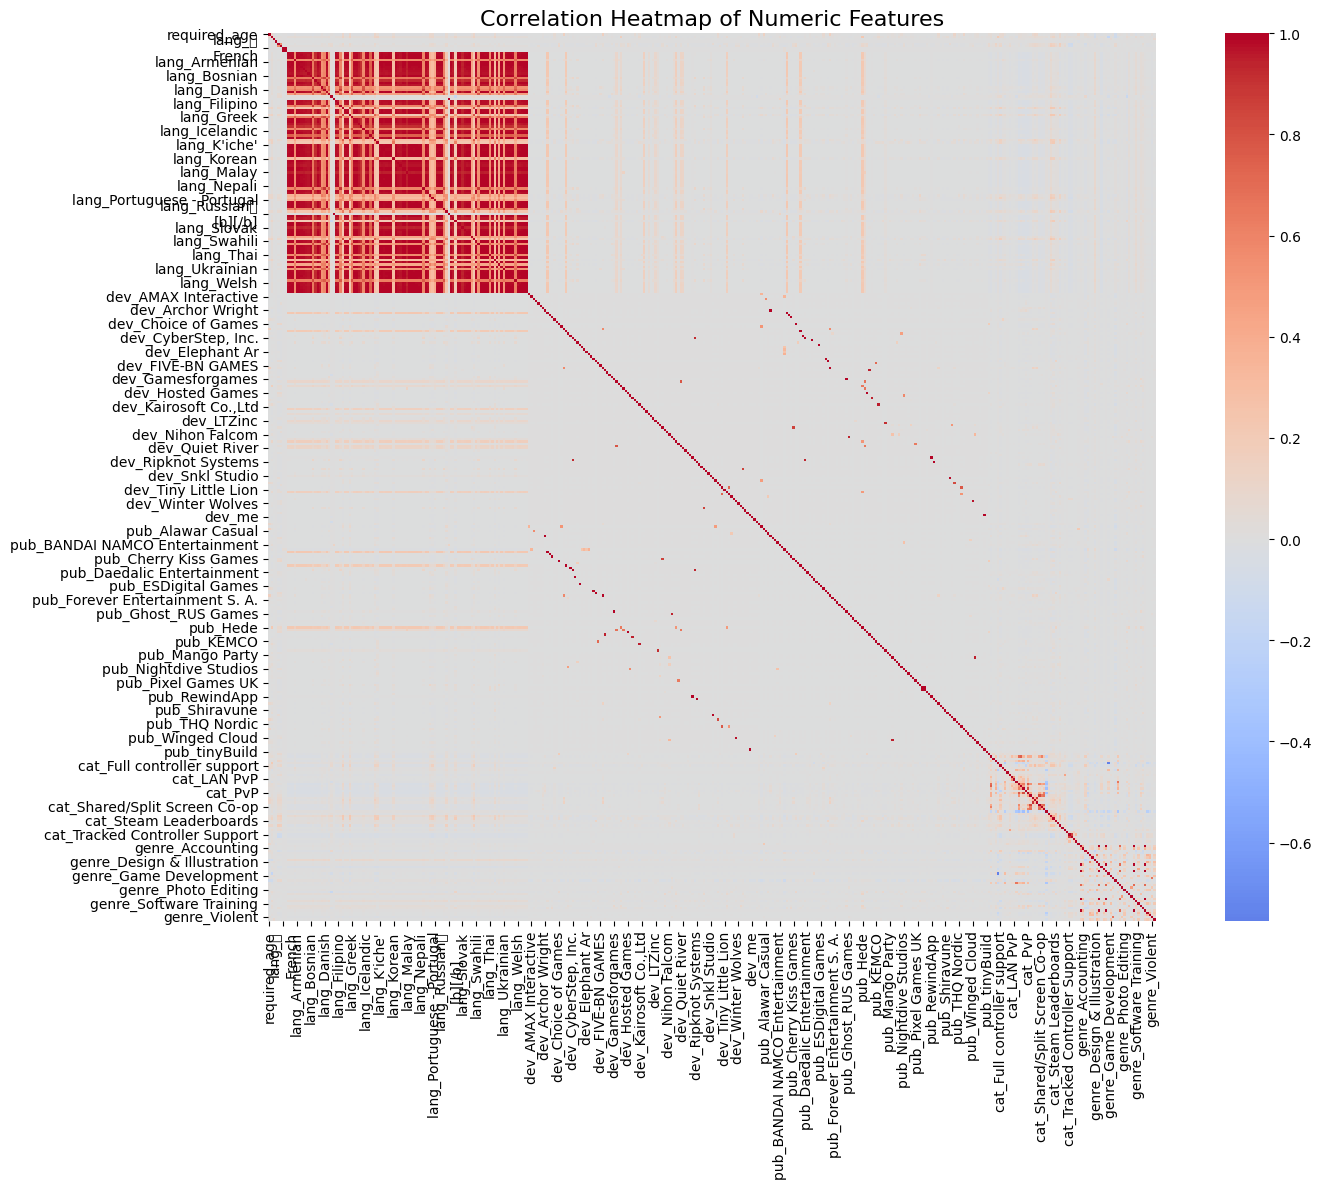

Number of numeric features: 386


In [92]:
# Select numeric features
numeric_df = df_clean.select_dtypes(include=['number'])

# Create correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

print(f"Number of numeric features: {numeric_df.shape[1]}")

In [93]:
# Find strongly correlated feature pairs
corr_matrix = numeric_df.corr()
threshold = 0.9

print(f"Feature pairs with correlation > {threshold}:\n")

corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        
        if corr_value > threshold or corr_value < -threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            corr_pairs.append((col1, col2, corr_value))
            print(f"{col1:30s} <--> {col2:30s} : {corr_value:.3f}")

if len(corr_pairs) == 0:
    print("No feature pairs with correlation > 0.9 found.")

Feature pairs with correlation > 0.9:

lang_
French                  <--> lang_
German                  : 1.000
lang_Afrikaans                 <--> lang_Albanian                  : 0.982
lang_Afrikaans                 <--> lang_Amharic                   : 0.981
lang_Afrikaans                 <--> lang_Armenian                  : 0.984
lang_Afrikaans                 <--> lang_Assamese                  : 0.981
lang_Afrikaans                 <--> lang_Azerbaijani               : 0.979
lang_Afrikaans                 <--> lang_Bangla                    : 0.970
lang_Afrikaans                 <--> lang_Basque                    : 0.971
lang_Afrikaans                 <--> lang_Belarusian                : 0.967
lang_Afrikaans                 <--> lang_Bosnian                   : 0.977
lang_Afrikaans                 <--> lang_Catalan                   : 0.928
lang_Afrikaans                 <--> lang_Cherokee                  : 0.977
lang_Afrikaans                 <--> lang_Croatian              

## V. Prepare Data for Classification

Create a binary classification target based on game popularity metrics.
This will likely create class imbalance, which SMOTE will address.

In [94]:
# Create a copy for modeling
df_model = df_clean.copy()

# Use average_playtime_forever as target for classification
target_col = 'average_playtime_forever'

# Ensure target is numeric
df_model[target_col] = pd.to_numeric(df_model[target_col], errors='coerce')
df_model = df_model.dropna(subset=[target_col])

# Calculate median
median_playtime = df_model[target_col].median()
print(f"Median playtime: {median_playtime:.2f}")

# Create binary target variable
# 1 = popular (above median), 0 = not popular (below median)
df_model['is_popular'] = (df_model[target_col] > median_playtime).astype(int)

print(f"\n=== Target Variable Distribution ===")
class_counts = df_model['is_popular'].value_counts()
print(class_counts)
print(f"\nClass Balance (proportions):")
print(df_model['is_popular'].value_counts(normalize=True))

# Calculate imbalance ratio
minority_class = class_counts.min()
majority_class = class_counts.max()
imbalance_ratio = majority_class / minority_class
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"(Majority class is {imbalance_ratio:.2f}x larger than minority class)")

Median playtime: 0.00

=== Target Variable Distribution ===
is_popular
0    80216
1     7915
Name: count, dtype: int64

Class Balance (proportions):
is_popular
0   0.91
1   0.09
Name: proportion, dtype: float64

Imbalance Ratio: 10.13:1
(Majority class is 10.13x larger than minority class)


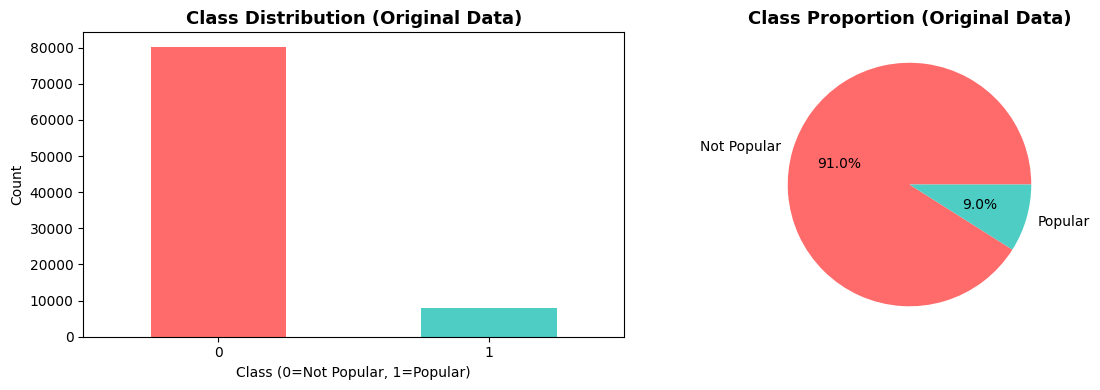

In [95]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
class_counts.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Class Distribution (Original Data)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class (0=Not Popular, 1=Popular)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df_model['is_popular'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                             colors=['#FF6B6B', '#4ECDC4'], labels=['Not Popular', 'Popular'])
axes[1].set_title('Class Proportion (Original Data)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [96]:
# Select only numeric features
df_model = df_model.select_dtypes(include=['number'])

# Drop the original playtime feature
df_model = df_model.drop(columns=['average_playtime_forever'], errors='ignore')

# Handle remaining NaNs
df_model = df_model.dropna()

# Separate features and target
X = df_model.drop(columns=['is_popular'])
y = df_model['is_popular']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

Features shape: (88131, 386)
Target shape: (88131,)

Target distribution:
is_popular
0    80216
1     7915
Name: count, dtype: int64


## VI. Feature Normalization

Scale features to [0, 1] range using MinMaxScaler.
Essential for Logistic Regression to converge efficiently.

In [97]:
# Normalize features
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

print(f"Normalized features shape: {X_normalized.shape}")
print(f"\nFeature statistics after normalization:")
print(X_normalized.describe())

Normalized features shape: (88131, 386)

Feature statistics after normalization:
       required_age   price  dlc_count  windows     mac   linux  \
count       8.8e+04 8.8e+04    8.8e+04  8.8e+04 8.8e+04 8.8e+04   
mean          0.054  0.0072    0.00017        1    0.19    0.14   
std            0.08   0.013     0.0045    0.014     0.4    0.35   
min               0       0          0        0       0       0   
25%           0.045 0.00099          0        1       0       0   
50%           0.045   0.005          0        1       0       0   
75%           0.045    0.01          0        1       0       0   
max               1       1          1        1       1       1   

       lang_\r\nFrench  lang_\r\nGerman  lang_Afrikaans  lang_Albanian  ...  \
count          8.8e+04          8.8e+04         8.8e+04        8.8e+04  ...   
mean           1.1e-05          1.1e-05           0.016          0.016  ...   
std             0.0034           0.0034            0.13           0.13  ...   

In [98]:
# Split data (without SMOTE yet)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.25, stratify=y, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 66098
Test set size: 22033

Training set class distribution:
is_popular
0    60162
1     5936
Name: count, dtype: int64

Test set class distribution:
is_popular
0    20054
1     1979
Name: count, dtype: int64


## VII. Understanding SMOTE (Synthetic Minority Over-sampling Technique)

### The Problem: Class Imbalance

When one class has far fewer examples:
- Model ignores the minority class
- High accuracy on majority class, poor on minority
- Real-world examples: fraud detection, disease diagnosis

### The Solution: SMOTE

SMOTE creates synthetic samples for the minority class:
1. Take a minority class sample
2. Find its k nearest neighbors (also minority class)
3. Randomly pick one neighbor
4. Create a new point between the two (interpolation)

**Key Advantage**: Synthetic samples are not duplicates—they're interpolations between real samples.
This prevents overfitting while balancing the dataset.

In [99]:
# Apply SMOTE to training data
print("=== BEFORE SMOTE ===")
print(f"Training set class distribution:")
print(Counter(y_train))
print(f"\nImbalance ratio: {max(Counter(y_train).values()) / min(Counter(y_train).values()):.2f}:1")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\n=== AFTER SMOTE ===")
print(f"Training set class distribution:")
print(Counter(y_train_smote))
print(f"\nImbalance ratio: {max(Counter(y_train_smote).values()) / min(Counter(y_train_smote).values()):.2f}:1")
print(f"\nNew synthetic samples created: {len(X_train_smote) - len(X_train)}")

=== BEFORE SMOTE ===
Training set class distribution:
Counter({0: 60162, 1: 5936})

Imbalance ratio: 10.14:1

=== AFTER SMOTE ===
Training set class distribution:
Counter({0: 60162, 1: 60162})

Imbalance ratio: 1.00:1

New synthetic samples created: 54226


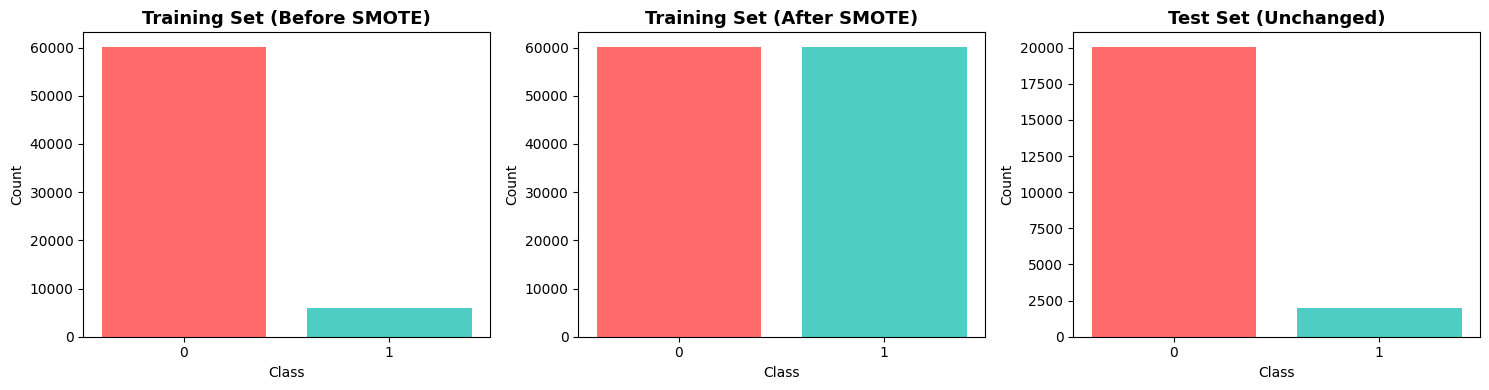

In [100]:
# Visualize the effect of SMOTE
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original training set
original_counts = Counter(y_train)
axes[0].bar(original_counts.keys(), original_counts.values(), color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Training Set (Before SMOTE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1])

# After SMOTE
smote_counts = Counter(y_train_smote)
axes[1].bar(smote_counts.keys(), smote_counts.values(), color=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Training Set (After SMOTE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_xticks([0, 1])

# Test set (unchanged)
test_counts = Counter(y_test)
axes[2].bar(test_counts.keys(), test_counts.values(), color=['#FF6B6B', '#4ECDC4'])
axes[2].set_title('Test Set (Unchanged)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Count')
axes[2].set_xticks([0, 1])

plt.tight_layout()
plt.show()

## VIII. Logistic Regression WITHOUT SMOTE

Train models on original imbalanced training data for comparison.

In [101]:
# Test different C values WITHOUT SMOTE
C_values = [1e-8, 1e-4, 1e-3, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15, 20, 100, 300, 1000, 5000]

train_accuracy_no_smote = []
test_accuracy_no_smote = []
test_f1_no_smote = []

for C in C_values:
    lr = LogisticRegression(C=C, solver='liblinear', random_state=42, max_iter=1000)
    lr.fit(X_train, y_train)
    
    train_accuracy_no_smote.append(lr.score(X_train, y_train))
    test_accuracy_no_smote.append(lr.score(X_test, y_test))
    
    y_pred = lr.predict(X_test)
    test_f1_no_smote.append(f1_score(y_test, y_pred))

# Find best C
best_C_no_smote = C_values[np.argmax(test_accuracy_no_smote)]
best_acc_no_smote = max(test_accuracy_no_smote)

print(f"Best C (without SMOTE): {best_C_no_smote}")
print(f"Best Test Accuracy: {best_acc_no_smote:.4f}")
print(f"Best F1-Score: {max(test_f1_no_smote):.4f}")

Best C (without SMOTE): 0.4
Best Test Accuracy: 0.9114
Best F1-Score: 0.2650


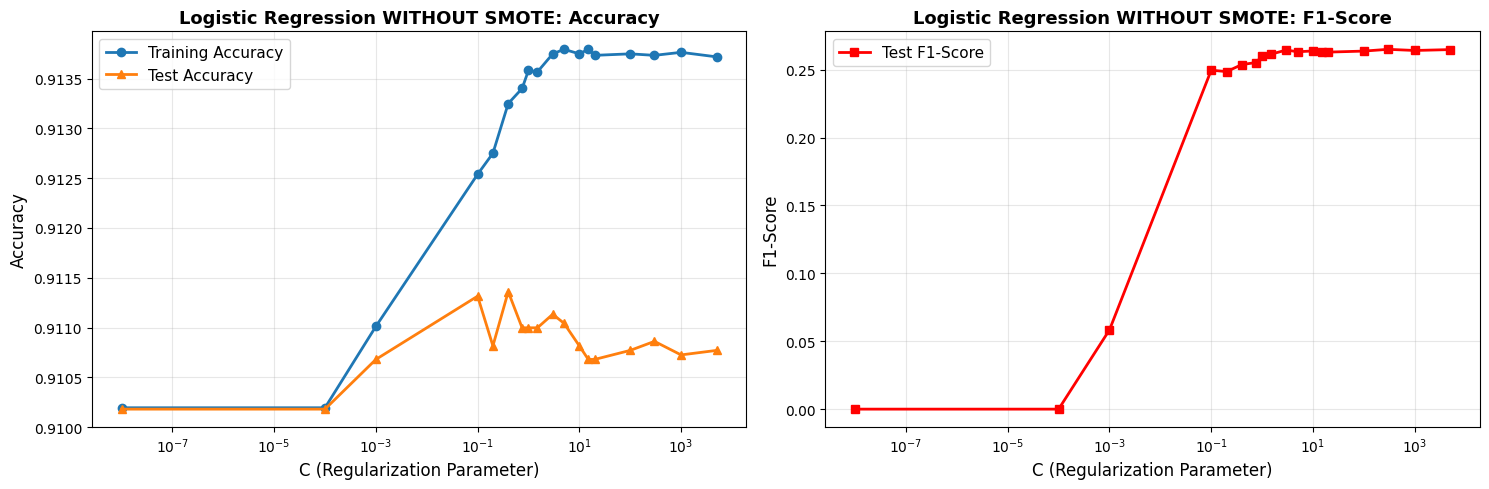

In [102]:
# Plot results WITHOUT SMOTE
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].set_xscale('log')  # ← fix
axes[0].plot(C_values, train_accuracy_no_smote, marker='o', label='Training Accuracy', linewidth=2)
axes[0].plot(C_values, test_accuracy_no_smote, marker='^', label='Test Accuracy', linewidth=2)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('C (Regularization Parameter)', fontsize=12)
axes[0].set_title('Logistic Regression WITHOUT SMOTE: Accuracy', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# F1-Score
axes[1].set_xscale('log')  # ← fix
axes[1].plot(C_values, test_f1_no_smote, marker='s', label='Test F1-Score', linewidth=2, color='red')
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_xlabel('C (Regularization Parameter)', fontsize=12)
axes[1].set_title('Logistic Regression WITHOUT SMOTE: F1-Score', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## IX. Logistic Regression WITH SMOTE

Train models on SMOTE-balanced training data.

In [103]:
# Test different C values WITH SMOTE
train_accuracy_with_smote = []
test_accuracy_with_smote = []
test_f1_with_smote = []
test_auc_with_smote = []

for C in C_values:
    lr = LogisticRegression(C=C, solver='liblinear', random_state=42, max_iter=1000)
    lr.fit(X_train_smote, y_train_smote)  # Train on SMOTE data
    
    train_accuracy_with_smote.append(lr.score(X_train_smote, y_train_smote))
    test_accuracy_with_smote.append(lr.score(X_test, y_test))
    
    y_pred = lr.predict(X_test)
    y_pred_proba = lr.predict_proba(X_test)[:, 1]
    test_f1_with_smote.append(f1_score(y_test, y_pred))
    test_auc_with_smote.append(roc_auc_score(y_test, y_pred_proba))

# Find best C
best_C_with_smote = C_values[np.argmax(test_f1_with_smote)]  # Use F1 for imbalanced data
best_f1_with_smote = max(test_f1_with_smote)

print(f"Best C (with SMOTE): {best_C_with_smote}")
print(f"Best Test Accuracy: {test_accuracy_with_smote[np.argmax(test_f1_with_smote)]:.4f}")
print(f"Best F1-Score: {best_f1_with_smote:.4f}")
print(f"Best AUC-ROC: {max(test_auc_with_smote):.4f}")

Best C (with SMOTE): 1000
Best Test Accuracy: 0.8239
Best F1-Score: 0.4202
Best AUC-ROC: 0.8334


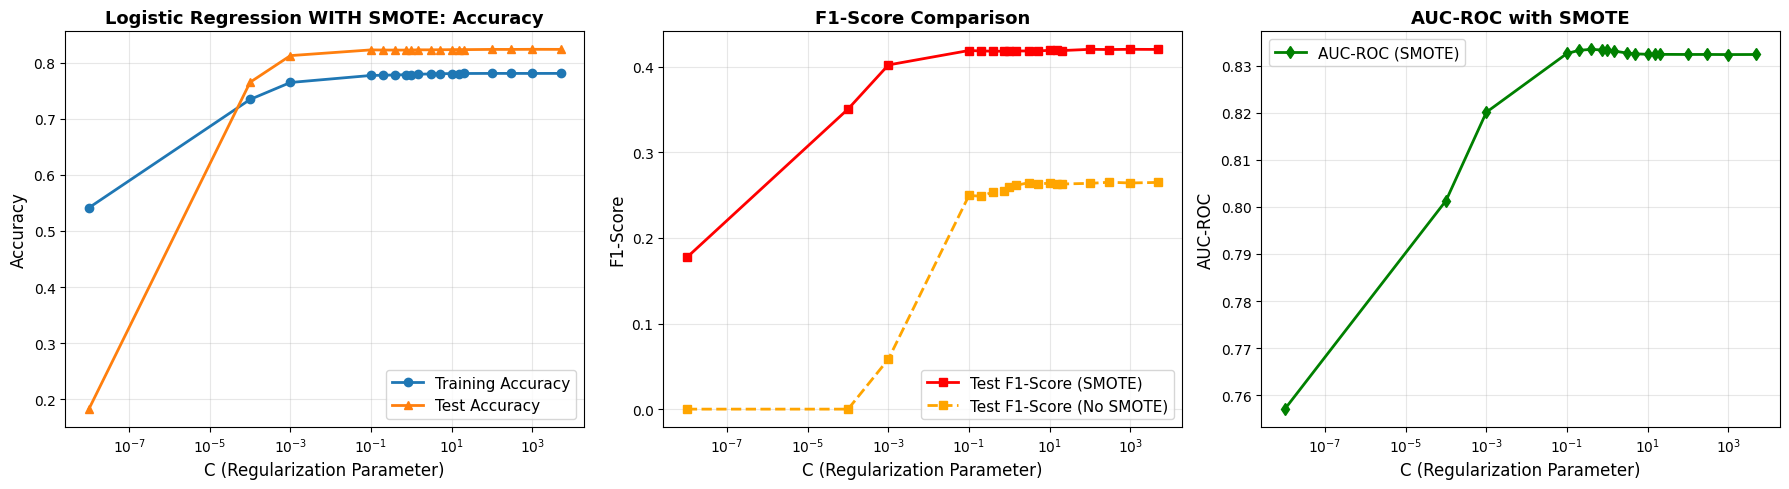

In [104]:
# Plot results WITH SMOTE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].set_xscale('log')  # ← fix
axes[0].plot(C_values, train_accuracy_with_smote, marker='o', label='Training Accuracy', linewidth=2)
axes[0].plot(C_values, test_accuracy_with_smote, marker='^', label='Test Accuracy', linewidth=2)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('C (Regularization Parameter)', fontsize=12)
axes[0].set_title('Logistic Regression WITH SMOTE: Accuracy', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# F1-Score
axes[1].set_xscale('log')  # ← fix
axes[1].plot(C_values, test_f1_with_smote, marker='s', label='Test F1-Score (SMOTE)', linewidth=2, color='red')
axes[1].plot(C_values, test_f1_no_smote, marker='s', label='Test F1-Score (No SMOTE)', linewidth=2, 
             linestyle='--', color='orange')
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_xlabel('C (Regularization Parameter)', fontsize=12)
axes[1].set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# AUC-ROC
axes[2].set_xscale('log')  # ← fix
axes[2].plot(C_values, test_auc_with_smote, marker='d', label='AUC-ROC (SMOTE)', linewidth=2, color='green')
axes[2].set_ylabel('AUC-ROC', fontsize=12)
axes[2].set_xlabel('C (Regularization Parameter)', fontsize=12)
axes[2].set_title('AUC-ROC with SMOTE', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## X. Logistic Regression with L1 Regularization and SMOTE

L1 regularization promotes feature selection by shrinking some weights to zero.

In [105]:
# Test L1 regularization with SMOTE
train_accuracy_l1_smote = []
test_accuracy_l1_smote = []
test_f1_l1_smote = []
num_features_selected = []

for C in C_values:
    lr_l1 = LogisticRegression(C=C, penalty="l1", solver='liblinear', random_state=42, max_iter=1000)
    lr_l1.fit(X_train_smote, y_train_smote)
    
    train_accuracy_l1_smote.append(lr_l1.score(X_train_smote, y_train_smote))
    test_accuracy_l1_smote.append(lr_l1.score(X_test, y_test))
    
    y_pred = lr_l1.predict(X_test)
    test_f1_l1_smote.append(f1_score(y_test, y_pred))
    
    # Count selected features (non-zero coefficients)
    num_features_selected.append(np.sum(lr_l1.coef_[0] != 0))

# Find best C
best_C_l1_smote = C_values[np.argmax(test_f1_l1_smote)]
best_f1_l1_smote = max(test_f1_l1_smote)

print(f"Best C for L1 with SMOTE: {best_C_l1_smote}")
print(f"Best Test Accuracy: {test_accuracy_l1_smote[np.argmax(test_f1_l1_smote)]:.4f}")
print(f"Best F1-Score: {best_f1_l1_smote:.4f}")
print(f"Features selected: {num_features_selected[np.argmax(test_f1_l1_smote)]} out of {X_train_smote.shape[1]}")

Best C for L1 with SMOTE: 0.1
Best Test Accuracy: 0.8264
Best F1-Score: 0.4240
Features selected: 178 out of 386


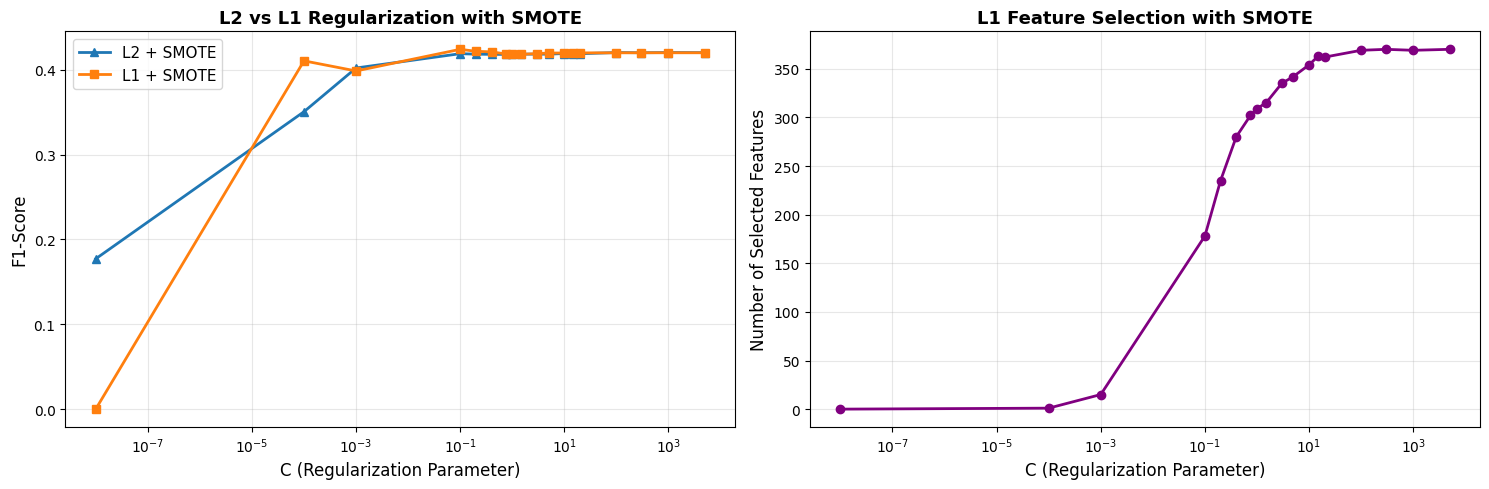

In [106]:
# Plot L1 results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# F1-Score comparison: L2 vs L1
axes[0].set_xscale('log')  # ← fix
axes[0].plot(C_values, test_f1_with_smote, marker='^', label='L2 + SMOTE', linewidth=2)
axes[0].plot(C_values, test_f1_l1_smote, marker='s', label='L1 + SMOTE', linewidth=2)
axes[0].set_ylabel('F1-Score', fontsize=12)
axes[0].set_xlabel('C (Regularization Parameter)', fontsize=12)
axes[0].set_title('L2 vs L1 Regularization with SMOTE', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Feature selection (sparsity) with L1
axes[1].set_xscale('log')  # ← fix
axes[1].plot(C_values, num_features_selected, marker='o', linewidth=2, color='purple')
axes[1].set_ylabel('Number of Selected Features', fontsize=12)
axes[1].set_xlabel('C (Regularization Parameter)', fontsize=12)
axes[1].set_title('L1 Feature Selection with SMOTE', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## XI. Comprehensive Model Comparison

Compare all models: with/without SMOTE, L1 vs L2 regularization.

In [107]:
# Train final best models for detailed comparison
models_summary = {}

# Model 1: L2 without SMOTE
lr_l2_no_smote = LogisticRegression(C=best_C_no_smote, solver='liblinear', random_state=42, max_iter=1000)
lr_l2_no_smote.fit(X_train, y_train)
models_summary['L2 (No SMOTE)'] = lr_l2_no_smote

# Model 2: L2 with SMOTE
lr_l2_with_smote = LogisticRegression(C=best_C_with_smote, solver='liblinear', random_state=42, max_iter=1000)
lr_l2_with_smote.fit(X_train_smote, y_train_smote)
models_summary['L2 (With SMOTE)'] = lr_l2_with_smote

# Model 3: L1 with SMOTE
lr_l1_with_smote = LogisticRegression(C=best_C_l1_smote, penalty="l1", solver='liblinear', random_state=42, max_iter=1000)
lr_l1_with_smote.fit(X_train_smote, y_train_smote)
models_summary['L1 (With SMOTE)'] = lr_l1_with_smote

# Evaluate all models
results = []
for name, model in models_summary.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': f"{accuracy_score(y_test, y_pred):.4f}",
        'Precision': f"{precision_score(y_test, y_pred):.4f}",
        'Recall': f"{recall_score(y_test, y_pred):.4f}",
        'F1-Score': f"{f1_score(y_test, y_pred):.4f}",
        'AUC-ROC': f"{roc_auc_score(y_test, y_pred_proba):.4f}"
    })

results_df = pd.DataFrame(results)
print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(results_df.to_string(index=False))


=== MODEL PERFORMANCE COMPARISON ===
          Model Accuracy Precision Recall F1-Score AUC-ROC
  L2 (No SMOTE)   0.9114    0.5204 0.1678   0.2537  0.8369
L2 (With SMOTE)   0.8239    0.2983 0.7105   0.4202  0.8323
L1 (With SMOTE)   0.8264    0.3020 0.7115   0.4240  0.8328


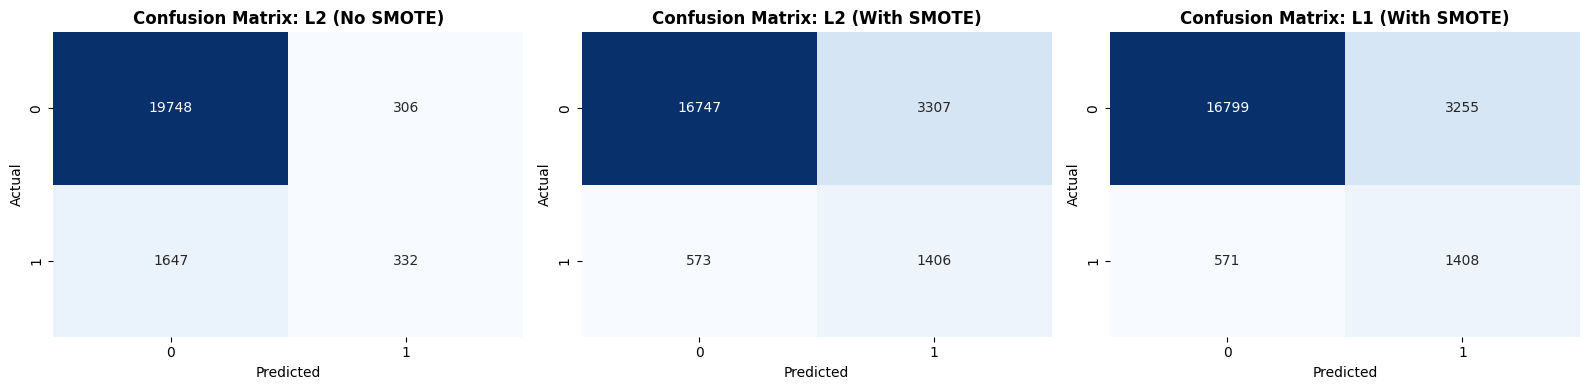

In [108]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (name, model) in enumerate(models_summary.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Confusion Matrix: {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

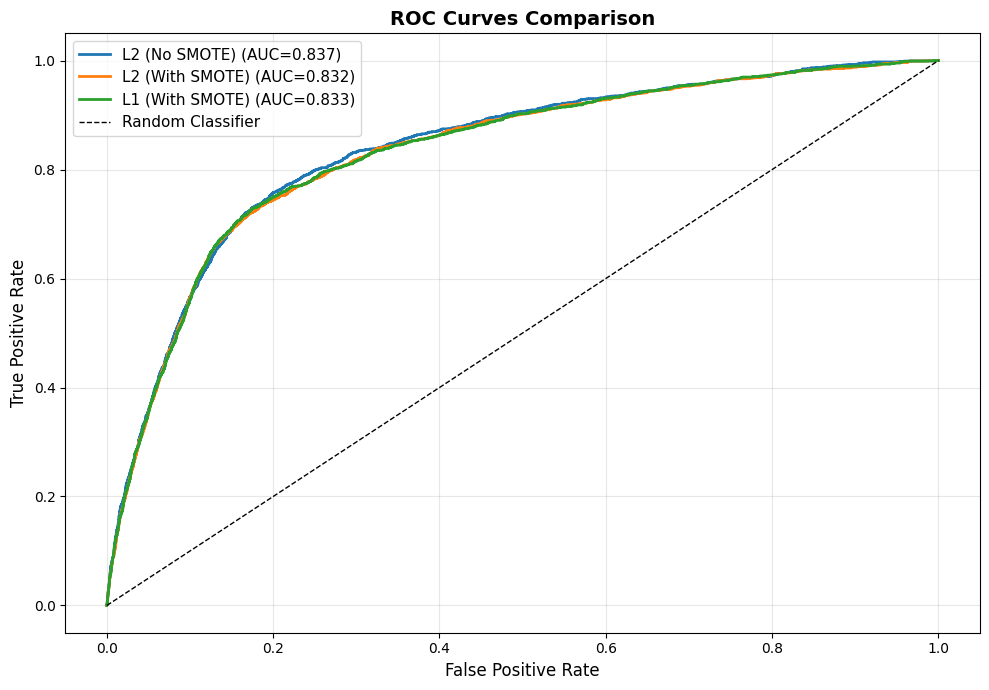

In [109]:
# ROC Curves
plt.figure(figsize=(10, 7))

for name, model in models_summary.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## XII. Feature Importance Analysis

Examine which features are most important for predictions.

In [110]:
# Get top features from best models
feature_importance_l2 = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient_L2_SMOTE': lr_l2_with_smote.coef_[0],
    'Coefficient_L1_SMOTE': lr_l1_with_smote.coef_[0]
})

# Add absolute values for ranking
feature_importance_l2['Abs_L2'] = np.abs(feature_importance_l2['Coefficient_L2_SMOTE'])
feature_importance_l2['Abs_L1'] = np.abs(feature_importance_l2['Coefficient_L1_SMOTE'])

# Top 15 features by L2
print("Top 15 Features (L2 + SMOTE):")
top_features_l2 = feature_importance_l2.nlargest(15, 'Abs_L2')[['Feature', 'Coefficient_L2_SMOTE', 'Abs_L2']]
print(top_features_l2.to_string(index=False))

Top 15 Features (L2 + SMOTE):
                       Feature  Coefficient_L2_SMOTE  Abs_L2
                     dlc_count                    22      22
                         price                    20      20
              lang_Azerbaijani                   -15      15
dev_KOEI TECMO GAMES CO., LTD.                    14      14
                 lang_Armenian                    13      13
pub_KOEI TECMO GAMES CO., LTD.                   -13      13
                    lang_Tamil                   -12      12
                   lang_Sindhi                    12      12
                    pub_8floor                   -11      11
         dev_Valkeala Software                  -9.4     9.4
                  lang_Marathi                   9.2     9.2
                      pub_Hede                  -9.1     9.1
            pub_Big Fish Games                  -8.7     8.7
                  lang_Maltese                     8       8
                  pub_HH-Games                  -7.9   

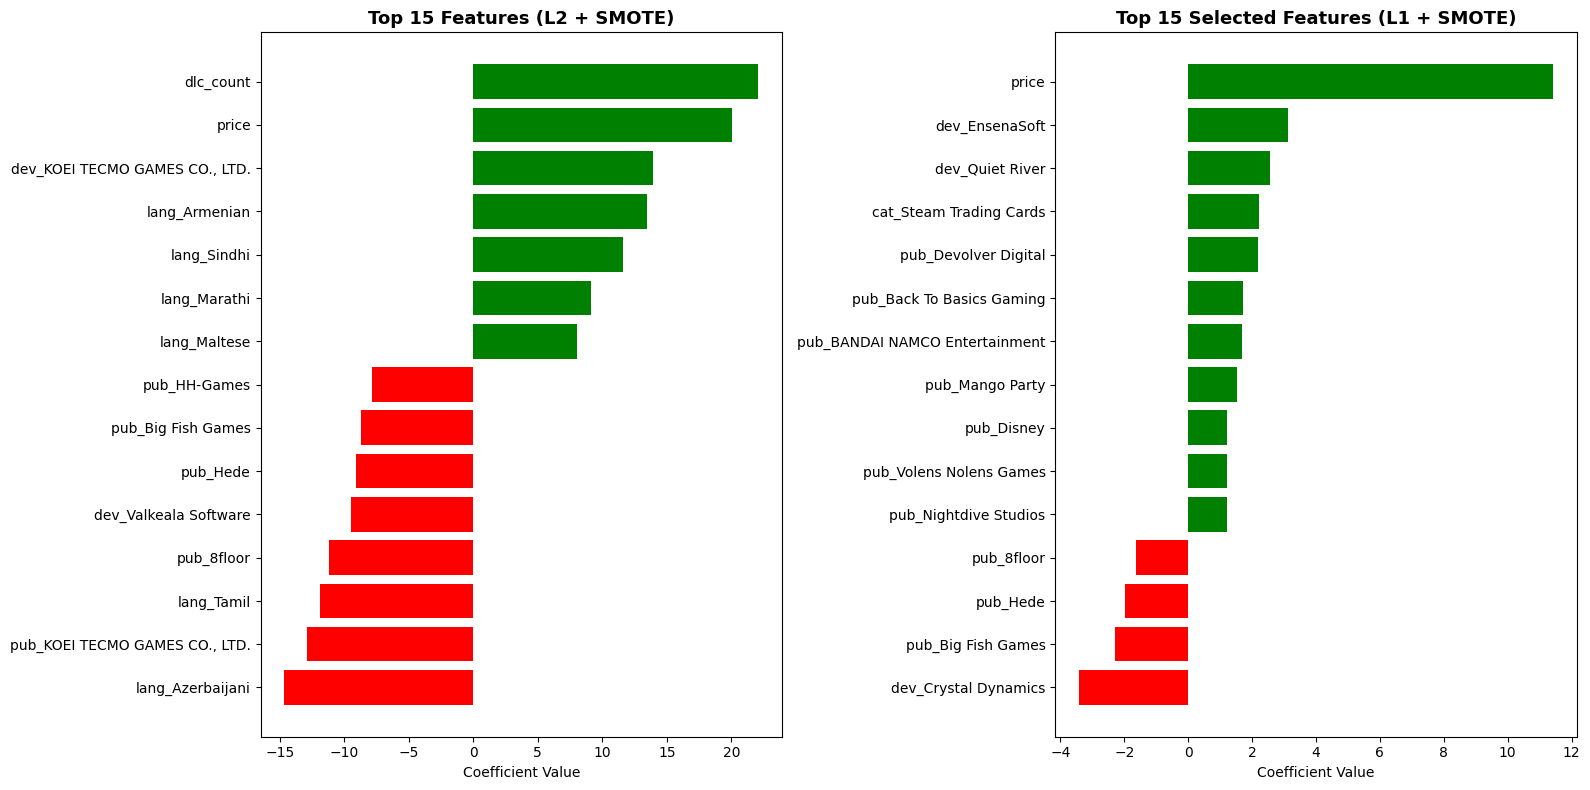

In [111]:
# Visualize top features
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# L2 features
top_l2 = feature_importance_l2.nlargest(15, 'Abs_L2').sort_values('Coefficient_L2_SMOTE')
colors = ['red' if x < 0 else 'green' for x in top_l2['Coefficient_L2_SMOTE']]
axes[0].barh(top_l2['Feature'], top_l2['Coefficient_L2_SMOTE'], color=colors)
axes[0].set_title('Top 15 Features (L2 + SMOTE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Coefficient Value')

# L1 selected features
l1_selected = feature_importance_l2[feature_importance_l2['Coefficient_L1_SMOTE'] != 0].nlargest(15, 'Abs_L1').sort_values('Coefficient_L1_SMOTE')
colors = ['red' if x < 0 else 'green' for x in l1_selected['Coefficient_L1_SMOTE']]
axes[1].barh(l1_selected['Feature'], l1_selected['Coefficient_L1_SMOTE'], color=colors)
axes[1].set_title('Top 15 Selected Features (L1 + SMOTE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

## XIII. Key Findings and Conclusions

### Summary of Results

This analysis demonstrates the importance of handling class imbalance in real-world datasets.

### Key Observations:

1. **Class Imbalance Problem**:
   - Original dataset has significant class imbalance
   - Model trained on imbalanced data ignores minority class
   - Accuracy alone is misleading for imbalanced datasets

2. **SMOTE Benefits**:
   - Creates synthetic minority samples through interpolation
   - Balances training data without simple duplication
   - Improves F1-score and recall on minority class
   - Better generalization to unseen data

3. **Regularization Effects**:
   - **L2**: Reduces all weights gradually (Ridge)
   - **L1**: Shrinks some weights to zero (feature selection)
   - L1 is useful when feature interpretability matters

4. **Evaluation Metrics**:
   - **Accuracy**: Misleading with imbalanced data
   - **Precision & Recall**: More informative for imbalanced classes
   - **F1-Score**: Harmonic mean of precision and recall
   - **AUC-ROC**: Threshold-independent evaluation

5. **Practical Recommendation**:
   - Always use SMOTE or similar techniques for imbalanced datasets
   - Monitor multiple metrics (not just accuracy)
   - Combine SMOTE with regularization for best results